 **Document très inspiré du livre *Python Data Science Handbook* de Jake VanderPlas** : https://github.com/jakevdp/PythonDataScienceHandbook 

# Histogrammes

In [1]:
import numpy as np
import matplotlib
import seaborn as sns
sns.set() # pour affichage un peu plus joli
from matplotlib import pyplot as plt
def makedata(N,p=0.3,rseed=1):
    rng=np.random.default_rng(rseed)
    rad=rng.binomial(n=1,p=0.3,size=N)
    x=rng.normal(0,1,N)
    y=rng.normal(5,1,N)
    z=rad*x+(1-rad)*y
    return z
x=makedata(1000) # simulation d'un mélange de deux gaussiennes, sigma=1, centres 0 et 5

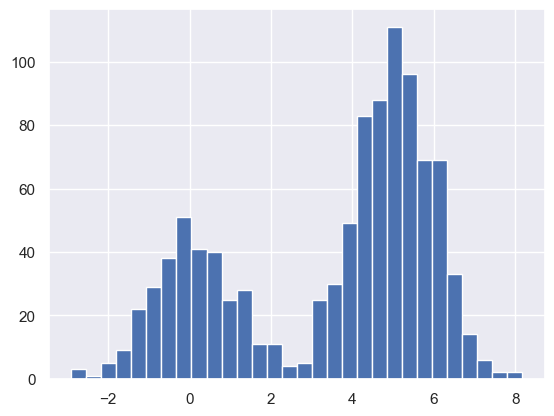

In [2]:
hist=plt.hist(x,bins=30) # histogramme standard avec 30 barres de même longueur

density=True pour que l'histogramme soit  un estimateur de la densité de X.

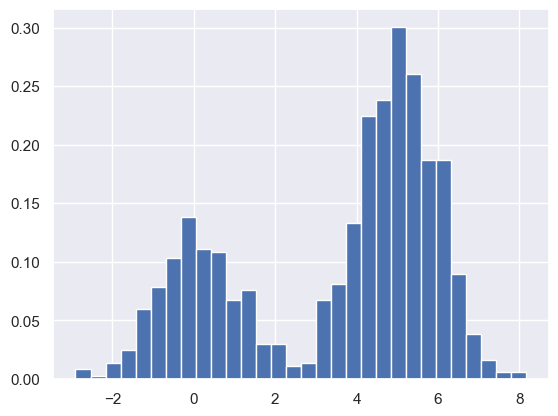

In [3]:
hist_density=plt.hist(x,bins=30,density=True)

On change le nombre de bins et leur emplacement :

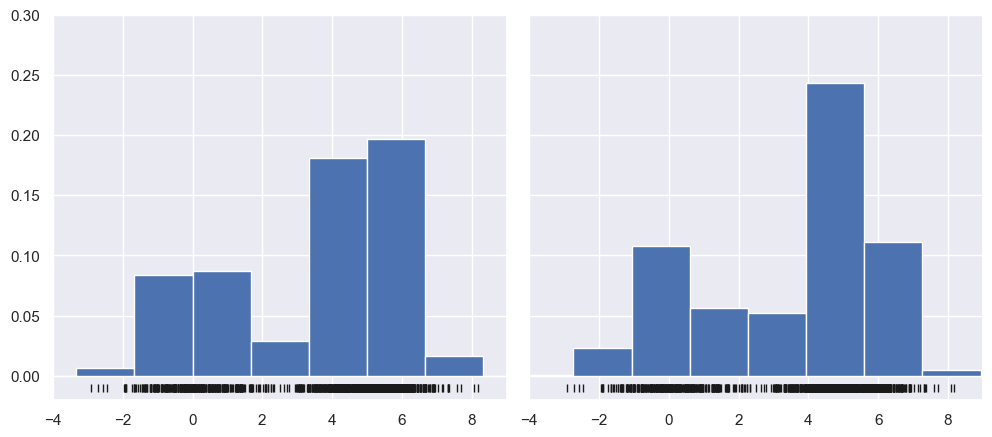

In [4]:
bins=np.linspace(-5,10,10)
fig,ax=plt.subplots(1,2,figsize=(12,5),sharex=True,sharey=True)
fig.subplots_adjust(wspace=0.05)
for i, offset in enumerate([0.0,0.6]):
    ax[i].hist(x,bins=bins+offset,density=True)
    ax[i].set_xlim(-4,9)
    ax[i].set_ylim(-0.02,0.3)
    ax[i].plot(x,np.full_like(x,-0.01),'|k',markeredgewidth=1) #  les traits verticaux noirs en bas du graphique :
                                                                # ces traits représentent les x_i

On remarque que le petit décalage (offset) dans le choix des `bins` a pas mal modifié l'apparence de l'histogramme (pas souhaitable bien sûr, pb qui n'existe pas avec les KDE). 

Il est possible de **choisir le nombre de bins par une méthode adaptative** (i.e. la méthode essaie 
de "deviner" le meilleur choix pour l'argument `bins` en utilisant les données). Par exemple on peut utiliser `stone` pour avoir accès à un choix par validation croisée :                                                                 

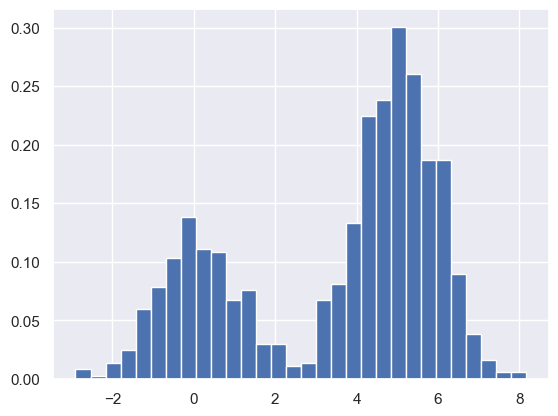

In [5]:
_=plt.hist(x,density=True,bins='stone')

# Estimateurs à noyaux

NB : l'argument `score_samples(x)` de `kde` calcule le vecteur $\Big(\log(\hat{f}(x_i))\Big)_{1\le i\le m}$ si $x$ est le vecteur $(x_1,\ldots,x_m)$.  

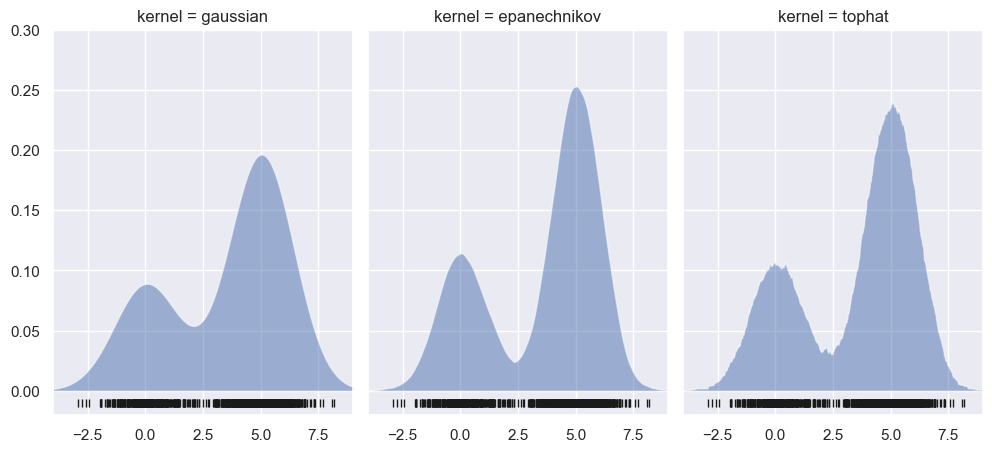

In [6]:
from sklearn.neighbors import KernelDensity

# définition et entraînement du modèle
kde_gaussien=KernelDensity(bandwidth=1,kernel='gaussian')
kde_gaussien.fit(x.reshape(-1,1))


# pour le reshape, cf. TP1YL (Yating Liu)

fig,ax=plt.subplots(1,3,figsize=(12,5),sharex=True,sharey=True)
fig.subplots_adjust(wspace=0.05)

xd=np.linspace(-5,10,2000)

for i, kernel in enumerate(['gaussian','epanechnikov','tophat']):
    kde=KernelDensity(bandwidth=1,kernel=kernel)
    kde.fit(x.reshape(-1,1))
    logprob=kde.score_samples(xd.reshape(-1,1)) 
    ax[i].fill_between(xd,np.exp(logprob),alpha=0.5)
    ax[i].set_xlim(-4,9)
    ax[i].set_ylim(-0.02,0.3)
    ax[i].plot(x,np.full_like(x,-0.01),'|k',markeredgewidth=1)
    ax[i].set_title(f'kernel = {kernel}')


plt.show()

`KernelDensity`est utilisé dans cet exemple pour estimer une densité sur $\mathbb{R}$ mais on peut aussi l'utiliser pour estimer une densité en toute dimension $d$ (attention au "curse of dimensionality" cependant, cf. poly cours). 

## **Choix de la fenêtre par validation croisée**

On peut utiliser `GridSearchCV` ou `cross_val_score` par exemple. 

In [7]:
from sklearn.model_selection import GridSearchCV
bandwidths=np.linspace(0.1,1,100)
kernels=['gaussian','exponential']
grid=GridSearchCV(KernelDensity(),
                  {'bandwidth':bandwidths,
                  'kernel':kernels},
                  cv=5,refit=True)    #knn cv=5 signifie 5 folds, c'est en fait la valeur par défaut
                                      # refit=True pour ré-entrainer, à la fin, l'estimateur avec le choix
                                      # final de h, sur toutes les données  
grid.fit(x.reshape(-1,1))
grid.best_params_

{'bandwidth': 0.2909090909090909, 'kernel': 'gaussian'}

Par défaut, GridSearchCV utilise la fonction `score` de l'estimateur, qui est ici  la log vraisemblance. 

In [8]:
estimator=grid.best_estimator_ # donne l'estimateur calculé sur toutes les données
# et avec les arguments (ici fenêtre et noyau) correspondant au meilleur score.
grid.best_params_

{'bandwidth': 0.2909090909090909, 'kernel': 'gaussian'}

In [9]:
import pandas as pd
results=pd.DataFrame(grid.cv_results_) # grid.cv_results_ est un dictionnaire
results.sort_values(ascending=False,by='mean_test_score',inplace=True)
results.loc[:,['mean_test_score','std_test_score','params']].head()

,mean_test_score,std_test_score,params
42,-403.470613,6.636920,"{'bandwidth': 0.2909090909090909, 'kernel': 'g..."
44,-403.470626,6.648240,"{'bandwidth': 0.3, 'kernel': 'gaussian'}"
46,-403.476292,6.658460,"{'bandwidth': 0.3090909090909091, 'kernel': 'g..."
40,-403.476430,6.624516,"{'bandwidth': 0.28181818181818186, 'kernel': '..."
48,-403.487489,6.667586,"{'bandwidth': 0.3181818181818182, 'kernel': 'g..."


Remarque sur l'utilisation de `GridSearchCV` versus un "cross validation estimator" :  
A cross validation  estimator has built-in cross-validation capabilities to automatically select the best hyper-parameters (ex : RidgeCV, LassoCV, LogisticRegressionCV). Cross-validation estimators are named EstimatorCV and tend to be roughly equivalent to GridSearchCV(Estimator(), ...). The advantage of using a cross-validation estimator over the canonical estimator class along with grid search is that they can take advantage of warm-starting by reusing precomputed results in the previous steps of the cross-validation process. This generally leads to speed improvements. 

Moreover the RidgeCV class can perform efficient Leave-One-Out (LOO) CV (grâce à une formule "sympathique"  qui évite certains calculs). Cette remarque est vraie aussi pour les estimateurs à noyau du chap5. 

By default, **all these estimators**, apart from RidgeCV with an LOO-CV, **will be refitted on the full training dataset after finding the best combination of hyper-parameters**.

# Remarque 4.19 "not naive" Bayes classifier 

In [10]:
# on va utiliser le dataset iris
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, train_test_split
iris = load_iris()
X,y=iris.data, iris.target
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,random_state=22,test_size=0.2)

In [11]:
from sklearn.base import BaseEstimator, ClassifierMixin

class KDEClassifier(BaseEstimator, ClassifierMixin):
    """Bayesian generative classification based on KDE
    Parameters
    ----------
    bandwidth : float
    the kernel bandwidth within each class
    kernel : str
    the kernel name, passed to KernelDensity
    """
    def __init__(self, bandwidth=1.0, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel
    def fit(self, X, y):
        self.classes_ = np.sort(np.unique(y))
        training_sets = [X[y == yi] for yi in self.classes_]# a list of training sets, one training set per class
        self.models_ = [KernelDensity(bandwidth=self.bandwidth, kernel=self.kernel).fit(Xi) for Xi in training_sets]
        self.logpriors_ = [np.log(Xi.shape[0] / X.shape[0]) for Xi in training_sets]
        return self # fit doit retourner self
    def predict_proba(self, X):
        logprobs = np.array([model.score_samples(X) for model in self.models_]).T 
        result = np.exp(logprobs + self.logpriors_)
        return result / result.sum(1, keepdims=True)
    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), 1)]

**Aide pour le code** (si besoin) :
- class KDEClassifier(BaseEstimator, ClassifierMixin): cette  ligne définit une nouvelle classe appelée KDEClassifier qui hérite de BaseEstimator et ClassifierMixin. Ces classes parentes viennent de scikit-learn et fournissent des fonctionnalités de base pour les estimateurs et les classificateurs (en particulier utile pour la CV ou les pipelines). BaseEstimator sert de point de départ pour créer n'importe quel type d'estimateur. ClassifierMixin est une autre classe de scikit-learn, utilisée  en combinaison avec BaseEstimator  pour fournir des fonctionnalités spécifiques aux classificateurs.
En particulier ClassifierMixin implémente une méthode `score` par défaut qui calcule la précision (accuracy) du modèle (en utilisant la méthode `predict`définie par l'utilisateur). 

- Un estimateur de scikit-learn doit obligatoirement définir les méthodes suivantes :

1. fit(X, y) :  entraîne le modèle sur les données d'apprentissage. Pour un apprentissage supervisé, elle prend deux arguments : X (les caractéristiques) et y (les étiquettes). Pour un apprentissage non supervisé, elle ne prend que X (ou bien on met y=None). 

2. predict(X) :   prend en entrée les  données X et retourne les prédictions.

In [ ]:
np.unique([1,3,4,3,1,2,4])

- self.models_ = [KernelDensity(bandwidth=self.bandwidth, kernel=self.kernel).fit(Xi) for Xi in training_sets] : donne la liste [$\hat{f}_1,\ldots, \hat{f}_K$] s'il y a K classes. 
       
- self.logpriors_ = [np.log(Xi.shape[0] / X.shape[0]) for Xi in training_sets] :  [$\log(\hat{p}_1), \ldots,\log(\hat{p}_K)]$

In [ ]:
# logprobs = np.array([model.score_samples(X) for model in self.models_]).T :  
KDE1=KernelDensity().fit(X,y)
KDE2=KernelDensity(bandwidth=2).fit(X,y)
print(X.shape)
print(KDE1.score_samples(X).shape)
print(np.array([KDE1.score_samples(X), KDE2.score_samples(X)]).shape)

- So the $i^{th}$ column of  logprobs corresponds to $\log(\hat{f}_i(X))$
  
- result = np.exp(logprobs + self.logpriors_)  = matrice $n\times K$  contenant  [ $\hat{p}_1 \hat{f}_1(X), \ldots, \hat{p}_K\hat{f}_K(X)]$ (avec n=nb de lignes de X)

- return result / result.sum(1, keepdims=True) : result.sum(1) signifie result.sum(axis=1) donc on somme les colonnes. Donc donne le vecteur $(\hat{\eta}(X_1), \ldots, \hat{\eta}(X_n))$. 

**Fin aide pour le code**

**Choix de la fenêtre par CV**

In [12]:
bandwidths = 10 ** np.linspace(-1, 1, 100)
grid = GridSearchCV(KDEClassifier(), {'bandwidth': bandwidths})
grid.fit(Xtrain, ytrain)
scores = grid.cv_results_['mean_test_score']


{'bandwidth': 0.1}
accuracy = 0.9583333333333334


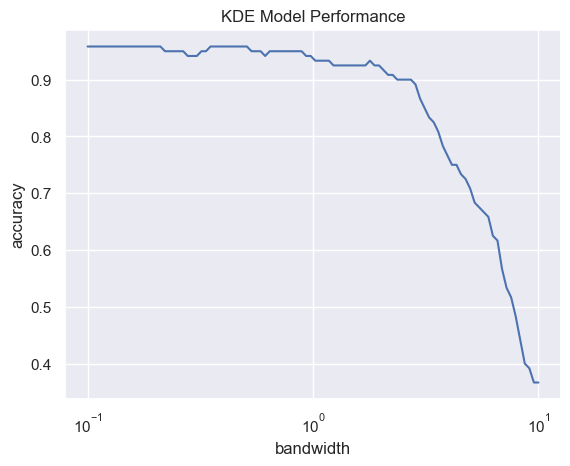

In [13]:
plt.semilogx(bandwidths, scores)
plt.xlabel('bandwidth')
plt.ylabel('accuracy')
plt.title('KDE Model Performance')
print(grid.best_params_)
print('accuracy =', grid.best_score_)

In [15]:
estimator = grid.best_estimator_
pred=estimator.predict(Xtest)
print('acurracy score ', (pred==ytest).mean())
# alternative 
print('accuracy score ', estimator.score(Xtest,ytest))

acuracy score  0.9666666666666667
accuracy score  0.9666666666666667


We also have access to $\hat{P}(Y=i\mid X=x)$ for $i\in \{1,,\ldots, K\}$ and for any data x : 

In [19]:
probas=estimator.predict_proba(Xtest)
probas[:20].round(2)

array([[1.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 0.  , 1.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 0.18, 0.82],
       [0.  , 1.  , 0.  ],
       [1.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 0.  , 1.  ],
       [0.  , 0.  , 1.  ],
       [1.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ],
       [0.  , 1.  , 0.  ]])